# Student Performance Prediction

Predicting final exam grades (G3) of secondary school students using demographic,
social, and academic features from the UCI Student Performance dataset.

**Goal:** Compare several regression models and identify which factors best explain
variation in final grades.

**Dataset:** [UCI Student Performance Data Set](https://archive.ics.uci.edu/dataset/320/student+performance) (Math course, 395 students, 33 features)

In [146]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

## 1. Load Data

In [112]:
data=pd.read_csv('D:/multi-media/data cleainig/ml_sklearn/student/student-mat.csv',sep=';')
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


## 2. Initial Inspection
Checking data types, missing values, and column names before any processing.

In [113]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [114]:
data.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## 3. Feature Grouping (Exploratory)
Grouping columns into semantic categories (demographics, family, study habits,
lifestyle) to guide the exploratory analysis below.

In [115]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [116]:
student=['school', 'sex', 'age', 'address', 'famsize', 'Pstatus']
stu_family=[ 'Medu', 'Fedu','Mjob', 'Fjob', 'guardian']
stu_studyPlan=['studytime','failures', 'schoolsup', 'famsup', 'paid','higher']
stu_life=[ 'activities','internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc','Walc','health', 'absences']
scores=['G1', 'G2', 'G3']
student=data[student]
stu_family=data[stu_family]
stu_studyPlan=data[stu_studyPlan]
stu_life=data[stu_life]
scores=data[scores]

## 4. Grade Distribution
Looking at the distribution of G1, G2, and G3 (first, second, and final period grades)
to understand the target variable before modeling.

In [117]:
G1Score=scores["G1"]
aveG1=np.mean(G1Score)
print(aveG1)
G2Score=scores["G2"]
aveG2=np.mean(G2Score)
print(aveG2)
G3Score=scores["G3"]
aveG3=np.mean(G3Score)
print(aveG3)

10.90886075949367
10.713924050632912
10.415189873417722


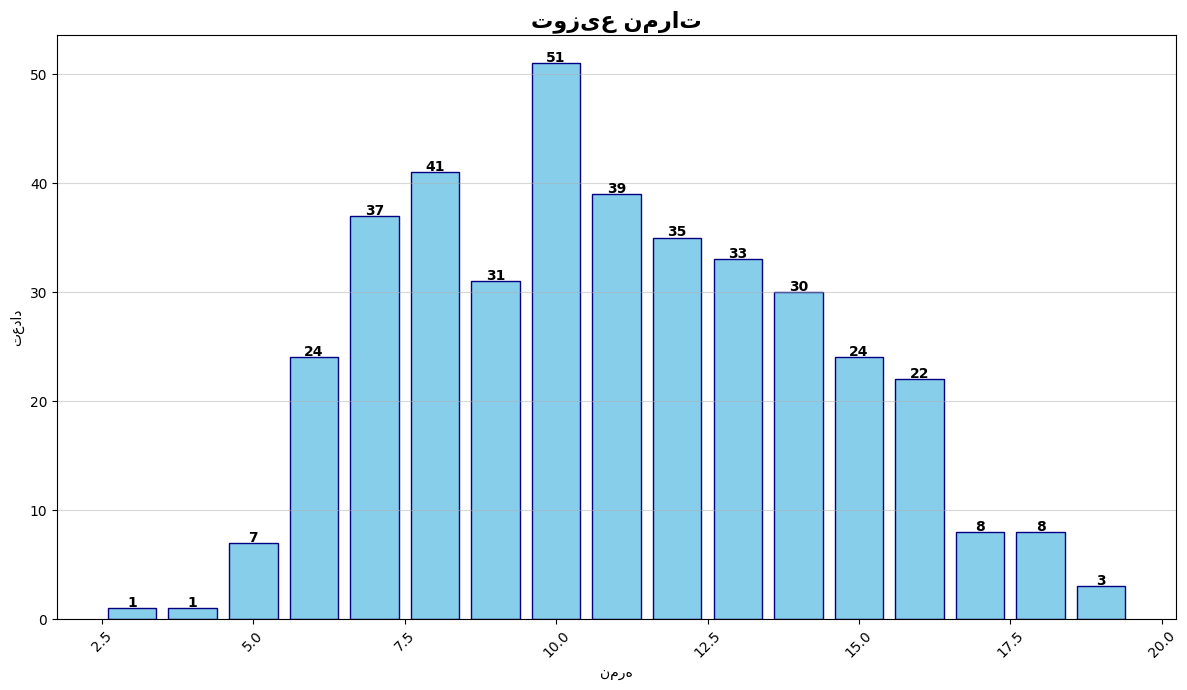

In [118]:
import matplotlib.pyplot as plt
import pandas as pd


freq = G1Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

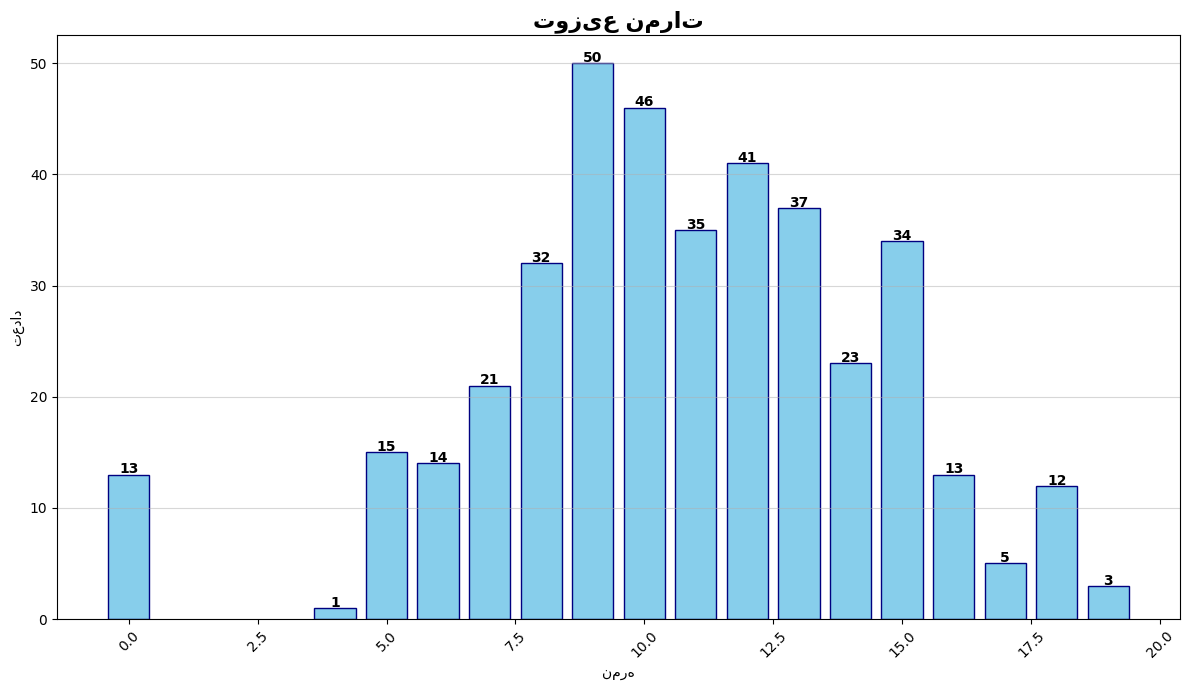

In [119]:
freq = G2Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

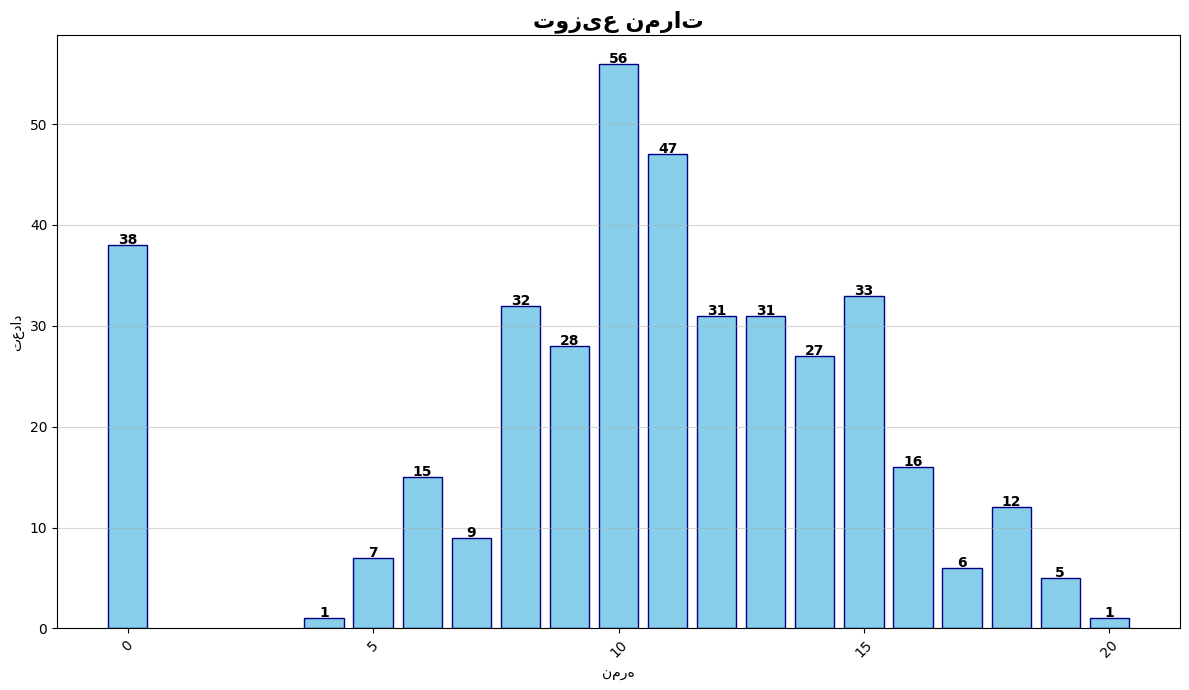

In [120]:
freq = G3Score.value_counts().sort_index()

plt.figure(figsize=(12, 7))
bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='navy')

plt.title('توزیع نمرات', fontsize=16, fontweight='bold')
plt.xlabel('نمره')
plt.ylabel('تعداد')

for i, v in enumerate(freq.values):
    plt.text(freq.index[i], v + 0.1, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Preprocessing Pipeline

Numerical features are standardized; categorical features are one-hot encoded.

> **Note on methodology:** G1 and G2 are grades from earlier periods of the *same*
> course and are strongly correlated with G3. Keeping them as features makes the
> prediction task considerably easier and less representative of predicting grades
> from demographic/behavioral factors alone. Results below include a comparison
> with and without G1/G2 (see Section 8).

In [121]:
target = data["G3"]
feature = data.drop(columns=["G2", "G3"])
x = feature
y = target


text_cols = x.select_dtypes(include=["object", "string"]).columns
x[text_cols] = x[text_cols].astype(object)

numerical_columns = x.select_dtypes(include=["int64"]).columns
categorical_columns = x.select_dtypes(include=["object"]).columns


numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)


## 6. Train/Test Split
80/20 split, fixed random state for reproducibility.

In [122]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

## 7. Fit Preprocessing on Training Data
Fitting the preprocessor only on the training set and applying the same
transformation to test data, to avoid data leakage.

In [123]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [124]:
print(x_train_processed.shape)
print(x_test_processed.shape)

(316, 57)
(79, 57)


## 8. Model Comparison
Training and evaluating six regression models with default hyperparameters,
using MAE, RMSE, and R² as comparison metrics.

In [125]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [126]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [127]:
results = pd.DataFrame(results)
results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,1.596835,2.328693,0.735538
5,Gradient Boosting,1.634615,2.358518,0.728720
4,SVR,1.920148,2.827239,0.610180
0,Linear Regression,2.272191,2.897703,0.590507
1,Decision Tree,2.139241,3.239394,0.488240
3,KNN,2.663291,3.493937,0.404654


In [128]:
rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['school','sex','age',...,'health','absences','G1']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with

In [129]:
rf = rf_pipe.named_steps["model"]

In [130]:
importance = rf.feature_importances_
print(importance)

[1.90076160e-02 8.78125287e-03 8.49252921e-03 8.08826745e-03
 5.28457369e-03 2.48812592e-02 8.73742121e-03 5.62669833e-03
 8.34511389e-03 2.07075804e-03 1.13637438e-02 7.76564809e-03
 1.63573026e-01 5.87852016e-01 9.40813124e-04 1.46711903e-03
 9.24656456e-04 9.69112279e-04 1.49916200e-03 1.55440217e-03
 1.25950048e-03 1.58559364e-03 1.08299997e-03 7.44746068e-04
 5.72206375e-03 9.00949478e-04 2.29102906e-03 5.45187093e-03
 2.88429861e-03 4.67198437e-03 1.85871506e-03 1.96069617e-03
 3.66995822e-03 2.24747526e-03 7.86406022e-03 5.09750940e-03
 1.12758922e-03 1.78436792e-03 2.21801573e-03 1.55591893e-03
 1.84174221e-03 1.31389126e-02 1.88083419e-02 6.14766190e-04
 9.35835462e-04 2.82419134e-03 1.47476422e-03 5.76712793e-03
 3.17493037e-03 1.59382643e-03 1.32031606e-03 3.95508871e-04
 9.38224553e-04 1.44760885e-03 1.84169082e-03 5.68677702e-03
 4.99090388e-03]


In [131]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc'
 'num__Walc' 'num__health' 'num__absences' 'num__G1' 'cat__school_GP'
 'cat__school_MS' 'cat__sex_F' 'cat__sex_M' 'cat__address_R'
 'cat__address_U' 'cat__famsize_GT3' 'cat__famsize_LE3' 'cat__Pstatus_A'
 'cat__Pstatus_T' 'cat__Mjob_at_home' 'cat__Mjob_health' 'cat__Mjob_other'
 'cat__Mjob_services' 'cat__Mjob_teacher' 'cat__Fjob_at_home'
 'cat__Fjob_health' 'cat__Fjob_other' 'cat__Fjob_services'
 'cat__Fjob_teacher' 'cat__reason_course' 'cat__reason_home'
 'cat__reason_other' 'cat__reason_reputation' 'cat__guardian_father'
 'cat__guardian_mother' 'cat__guardian_other' 'cat__schoolsup_no'
 'cat__schoolsup_yes' 'cat__famsup_no' 'cat__famsup_yes' 'cat__paid_no'
 'cat__paid_yes' 'cat__activities_no' 'cat__activities_yes'
 'cat__nursery_no' 'cat__nursery_yes' 'cat__higher_no' 'cat__higher_yes'
 'cat__internet_no' 'cat__internet_yes' 'cat__romantic_n

In [132]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
top10=importance_df.head(10)
top10

,Feature,Importance
13,num__G1,0.587852
12,num__absences,0.163573
5,num__failures,0.024881
0,num__age,0.019008
42,cat__schoolsup_yes,0.018808
41,cat__schoolsup_no,0.013139
10,num__Walc,0.011364
1,num__Medu,0.008781
6,num__famrel,0.008737
2,num__Fedu,0.008493


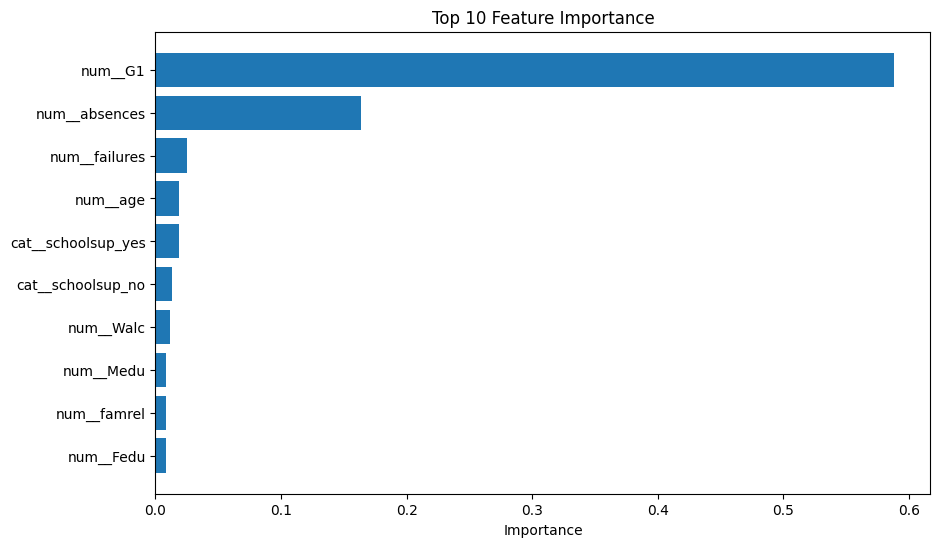

In [133]:
plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Feature Importance")

plt.show()

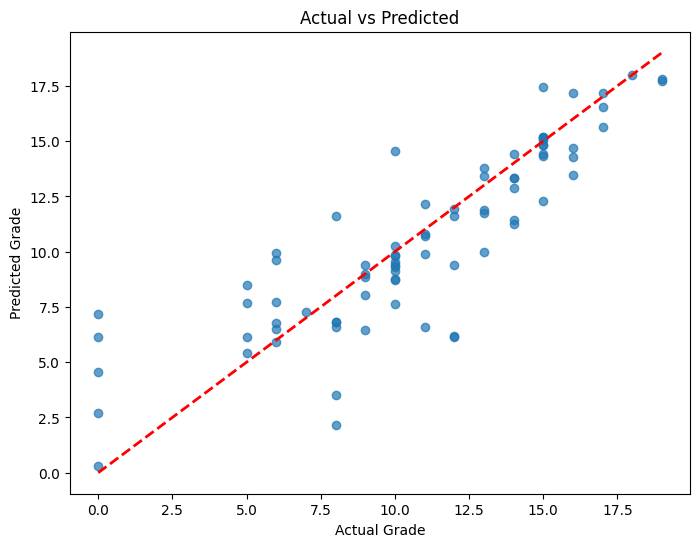

In [134]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Grade")

plt.ylabel("Predicted Grade")

plt.title("Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

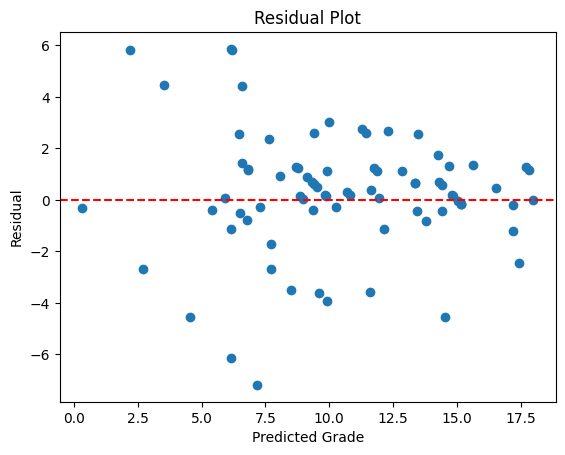

In [135]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Grade")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


In [136]:
errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

errors["Absolute Error"] = errors["Residual"].abs()

errors = errors.sort_values(
    by="Absolute Error",
    ascending=False
)

errors.head(10)
# x_test.loc[errors.index[:10]]

,Actual,Predicted,Residual,Absolute Error
140,0,7.180729,-7.180729,7.180729
316,0,6.151626,-6.151626,6.151626
33,12,6.142357,5.857643,5.857643
90,8,2.181082,5.818918,5.818918
30,12,6.183030,5.816970,5.816970
76,10,14.552083,-4.552083,4.552083
334,0,4.539031,-4.539031,4.539031
124,8,3.538067,4.461933,4.461933
145,11,6.586185,4.413815,4.413815
234,6,9.927309,-3.927309,3.927309


In [137]:
x_test.loc[errors.index[:10]]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1
140,GP,M,15,U,GT3,T,4,3,teacher,services,...,yes,no,2,2,2,1,1,3,0,7
316,GP,F,18,U,GT3,T,2,1,services,other,...,yes,no,5,3,3,1,2,1,0,8
33,GP,M,15,U,LE3,T,3,3,other,other,...,yes,no,5,3,2,1,1,2,0,8
90,GP,F,16,U,GT3,T,3,3,other,other,...,yes,yes,4,3,3,1,3,4,0,7
30,GP,M,15,U,GT3,T,4,4,health,services,...,yes,no,5,4,2,3,4,5,0,9
76,GP,M,15,U,GT3,T,4,0,teacher,other,...,yes,no,3,4,3,1,1,1,8,11
334,GP,F,18,R,GT3,T,2,2,at_home,other,...,no,no,4,4,4,1,1,4,0,10
124,GP,F,16,U,GT3,T,2,2,other,other,...,yes,yes,5,4,4,1,1,5,0,8
145,GP,F,15,U,GT3,T,1,1,other,services,...,yes,no,4,4,2,1,2,5,0,8
234,GP,M,16,U,LE3,T,1,1,other,other,...,yes,no,3,4,2,1,1,5,18,9


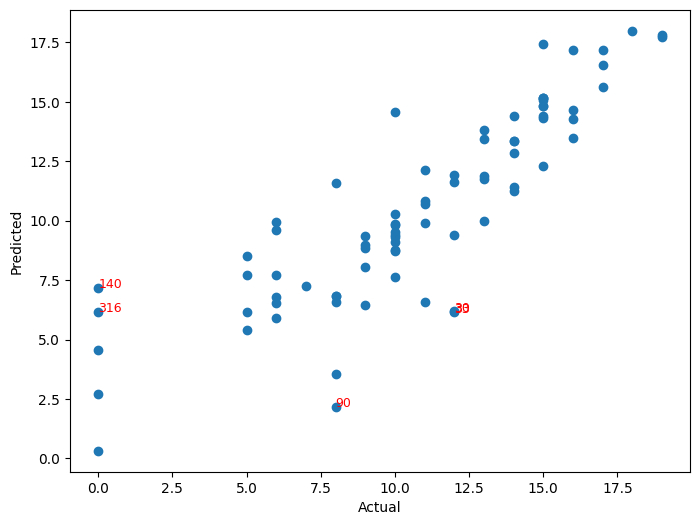

In [138]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

for i in errors.head(5).index:
    plt.text(
        y_test.loc[i],
        y_pred[list(y_test.index).index(i)],
        str(i),
        fontsize=9,
        color="red"
    )

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [139]:
data[["G1", "G3"]].corr()

,G1,G3
G1,1.000000,0.801468
G3,0.801468,1.000000


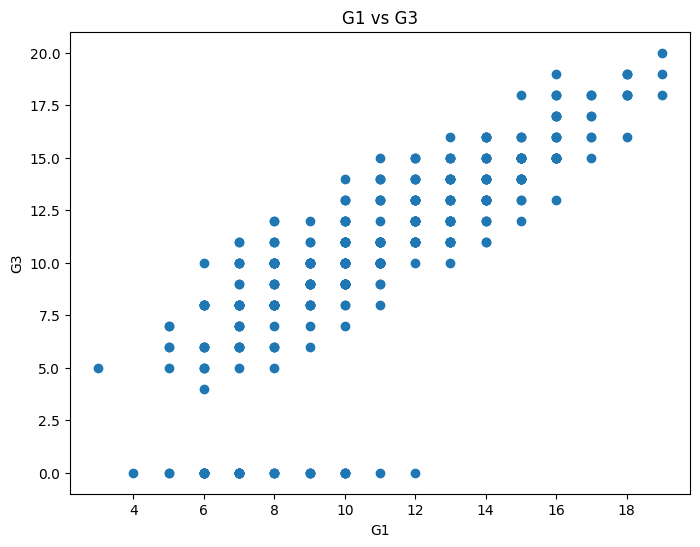

In [140]:
plt.figure(figsize=(8,6))

plt.scatter(data["G1"], data["G3"])

plt.xlabel("G1")

plt.ylabel("G3")

plt.title("G1 vs G3")

plt.show()

In [145]:
scores = cross_val_score(
    pipe,
    x,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)
scoring="neg_mean_absolute_error"
mae_scores = -scores
print(mae_scores)
print(mae_scores.mean())
print(mae_scores.std())

[1.74127243 2.51891307 1.436466   1.75341355 1.70286692]
1.8305863945438816
0.363144431504973


In [151]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
grid_search.fit(x, y)
print(grid_search.best_params_)


{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [152]:
best_mae = -grid_search.best_score_
print(best_mae)

1.845732766166326
